In [2]:
import msprime
import numpy as np  # Importing NumPy for numerical operations
import os  # Importing os for operating system functionalities
import argparse  # Importing argparse for command-line argument parsing
import pandas as pd  # Importing pandas for DataFrame manipulation
import zipfile  # Importing zipfile for creating zip archives
import gzip
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
     


In [1]:
import msprime
print(msprime.__file__)

/data/proj2/home/students/u.srinivasan/.conda/envs/scikit-allel/lib/python3.9/site-packages/msprime/__init__.py


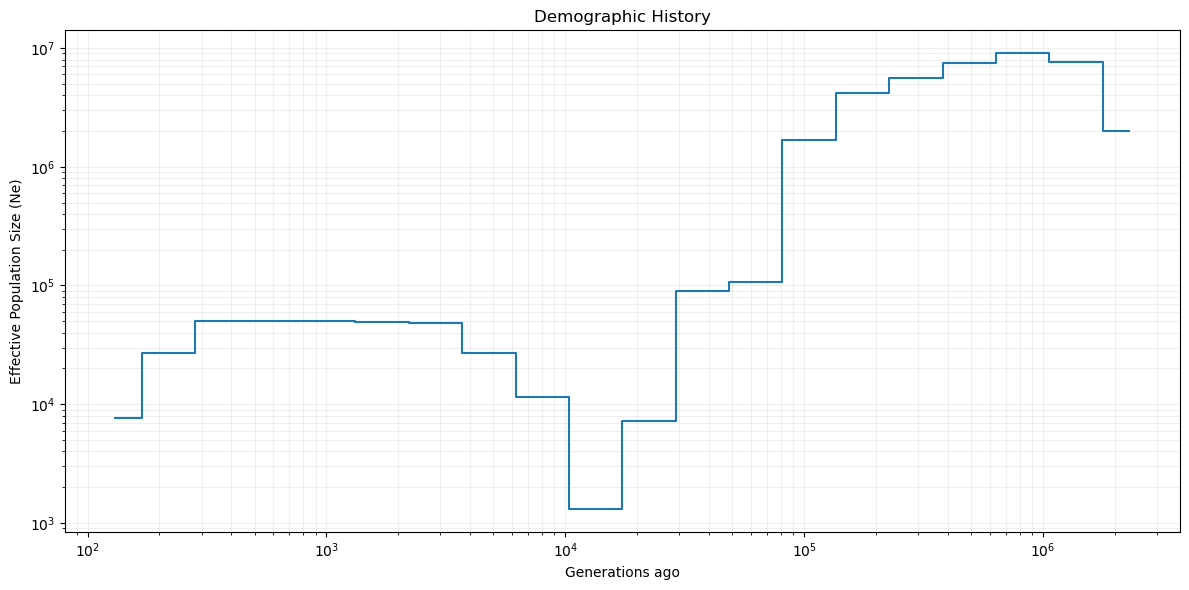

In [65]:
# User-defined parameters
num_time_points = 39  # Number of time points for demographic changes


# Demographic data
demography_data = {
    'years_ago': [
        20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
        75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
        273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
        990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
        3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
        12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
        46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
        169890.48403, 219724.30843, 284175.84417, 367532.89150
    ],
    'Ne_log10': [
        3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
        4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
        4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
        4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
        3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
        6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
        6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
        6.885372, 6.885372, 6.300497, 6.300497
    ]
}

# Convert to DataFrame for easier manipulation
demography_df = pd.DataFrame(demography_data)


# Assuming you've already created demography_df as shown in your code

# Define generation time
generation_time = 0.16

# Convert years to generations
demography_df['generations_ago'] = demography_df['years_ago'] / generation_time

# Convert Ne_log10 to actual population size
demography_df['Ne'] = 10 ** demography_df['Ne_log10']

# Create the plot
plt.figure(figsize=(12, 6))
plt.step(demography_df['generations_ago'], demography_df['Ne'], where='post')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Generations ago')
plt.ylabel('Effective Population Size (Ne)')
plt.title('Demographic History')
plt.grid(True, which="both", ls="-", alpha=0.2)



plt.tight_layout()
plt.show()


In [83]:
# Function to generate population times
def get_population_time(num_time_points):
    """Generate population times."""
    divided_gens = demography_df['years_ago'] / 0.16  # Divide years_ago by generation time
    divided_gens=divided_gens.sort_values()
    return divided_gens

def sample_population_size(num_time_points, demography_fromdata):
    """Sample population sizes based on demographic data."""
    pop_sizes = np.zeros(num_time_points)
    
    # Ensure demography_df has enough rows
    total_rows = len(demography_fromdata)
    if total_rows == 0:
        raise ValueError("The demography DataFrame is empty.")
    
    # Adjust the loop to prevent out-of-bounds indexing
    for i in range(num_time_points):
        if i >= total_rows:
            raise IndexError(f"Index {i} is out of bounds for demography DataFrame with {total_rows} rows.")
        
        log10_Ne = demography_fromdata['Ne_log10'].iloc[i]
        Ne = 10 ** log10_Ne
        pop_sizes[i] = np.random.uniform(max(0, Ne - 1000), Ne + 1000)  # Sample within ±1000 around the population size
    
    return pop_sizes

In [86]:
population_times = get_population_time(num_time_points)
#print(demography_df['generations_ago'] )
print(population_times)
smooth_pop_sizes = sample_population_size(num_time_points, demography_df)


0     1.306869e+02
1     1.690212e+02
2     2.186001e+02
3     2.827219e+02
4     3.656524e+02
5     4.729089e+02
6     6.116269e+02
7     7.910348e+02
8     1.023068e+03
9     1.323164e+03
10    1.711287e+03
11    2.213257e+03
12    2.862469e+03
13    3.702115e+03
14    4.788053e+03
15    6.192529e+03
16    8.008977e+03
17    1.035824e+04
18    1.339662e+04
19    1.732624e+04
20    2.240853e+04
21    2.898160e+04
22    3.748274e+04
23    4.847753e+04
24    6.269739e+04
25    8.108837e+04
26    1.048739e+05
27    1.356365e+05
28    1.754227e+05
29    2.268792e+05
30    2.934295e+05
31    3.795009e+05
32    4.908196e+05
33    6.347913e+05
34    8.209941e+05
35    1.061816e+06
36    1.373277e+06
37    1.776099e+06
38    2.297081e+06
Name: years_ago, dtype: float64


In [87]:
# Create a Demography object
demography = msprime.Demography()

# Add a single population
demography.add_population(name="pop", initial_size=smooth_pop_sizes[0])
demography


id,name,description,initial_size,growth_rate,default_sampling_time,extra_metadata
0,pop,,6772.5,0,0,{}


In [41]:
demography.add_population_parameters_change(time=population_times[1], initial_size=smooth_pop_sizes[1], population="pop")
demography
# Add population size changes
#for t, size in zip(population_times[1:], smooth_pop_sizes[1:]):
 #   demography.add_population_parameters_change(time=t, initial_size=size, population="pop")

Demography(populations=[Population(initial_size=8593.592278188718, growth_rate=0, name='pop', description='', extra_metadata={}, default_sampling_time=None, initially_active=None, id=0)], events=[PopulationParametersChange(time=60576.73654111843, initial_size=27879.59516237516, growth_rate=None, population='pop'), PopulationParametersChange(time=60576.73654111843, initial_size=27879.59516237516, growth_rate=None, population='pop')], migration_matrix=array([[0.]]))

In [88]:
# Create a Demography object
demography = msprime.Demography()

# Add a single population
demography.add_population(name="pop", initial_size=smooth_pop_sizes[0])

# Add population size changes
for t, size in zip(population_times[1:], smooth_pop_sizes[1:]):
    demography.add_population_parameters_change(time=t, initial_size=size, population="pop")

In [89]:
demography

Demography(populations=[Population(initial_size=6772.476820546183, growth_rate=0, name='pop', description='', extra_metadata={}, default_sampling_time=None, initially_active=None, id=0)], events=[PopulationParametersChange(time=169.02124999999998, initial_size=26661.39430333125, growth_rate=None, population='pop'), PopulationParametersChange(time=218.6000625, initial_size=27191.092960826423, growth_rate=None, population='pop'), PopulationParametersChange(time=282.721875, initial_size=50947.33815155208, growth_rate=None, population='pop'), PopulationParametersChange(time=365.6524375, initial_size=51144.97144785011, growth_rate=None, population='pop'), PopulationParametersChange(time=472.9089375, initial_size=50108.378119456094, growth_rate=None, population='pop'), PopulationParametersChange(time=611.6268749999999, initial_size=49472.45638844896, growth_rate=None, population='pop'), PopulationParametersChange(time=791.0348124999999, initial_size=50745.59601199789, growth_rate=None, population='pop'), PopulationParametersChange(time=1023.0683750000001, initial_size=50688.86073042564, growth_rate=None, population='pop'), PopulationParametersChange(time=1323.1640625, initial_size=49938.66401241849, growth_rate=None, population='pop'), PopulationParametersChange(time=1711.286625, initial_size=48473.64273752057, growth_rate=None, population='pop'), PopulationParametersChange(time=2213.2568125, initial_size=48222.542005422416, growth_rate=None, population='pop'), PopulationParametersChange(time=2862.4694375, initial_size=48712.6357143784, growth_rate=None, population='pop'), PopulationParametersChange(time=3702.1150624999996, initial_size=27885.501877075076, growth_rate=None, population='pop'), PopulationParametersChange(time=4788.053187500001, initial_size=26128.842494574285, growth_rate=None, population='pop'), PopulationParametersChange(time=6192.5285625, initial_size=11563.794146622473, growth_rate=None, population='pop'), PopulationParametersChange(time=8008.9775, initial_size=10966.301096768422, growth_rate=None, population='pop'), PopulationParametersChange(time=10358.2436875, initial_size=1076.917234008647, growth_rate=None, population='pop'), PopulationParametersChange(time=13396.618125, initial_size=2282.219290423635, growth_rate=None, population='pop'), PopulationParametersChange(time=17326.236187500002, initial_size=7439.1247159304985, growth_rate=None, population='pop'), PopulationParametersChange(time=22408.525625, initial_size=7041.037499729072, growth_rate=None, population='pop'), PopulationParametersChange(time=28981.5985, initial_size=89627.49108524679, growth_rate=None, population='pop'), PopulationParametersChange(time=37482.7449375, initial_size=89943.83149008072, growth_rate=None, population='pop'), PopulationParametersChange(time=48477.525187499996, initial_size=105981.07061283002, growth_rate=None, population='pop'), PopulationParametersChange(time=62697.3944375, initial_size=107012.59655429237, growth_rate=None, population='pop'), PopulationParametersChange(time=81088.3653125, initial_size=1667269.9824526333, growth_rate=None, population='pop'), PopulationParametersChange(time=104873.94331249999, initial_size=1667535.557835659, growth_rate=None, population='pop'), PopulationParametersChange(time=135636.52375, initial_size=4180407.627243799, growth_rate=None, population='pop'), PopulationParametersChange(time=175422.66449999998, initial_size=4180350.2112086075, growth_rate=None, population='pop'), PopulationParametersChange(time=226879.2384375, initial_size=5573401.178260243, growth_rate=None, population='pop'), PopulationParametersChange(time=293429.5234375, initial_size=5573424.954520961, growth_rate=None, population='pop'), PopulationParametersChange(time=379500.94425, initial_size=7455498.311020438, growth_rate=None, population='pop'), PopulationParametersChange(time=490819.6183125, initial_size=7456073.455011706, growth_rate=None, population='pop'), PopulationParametersChange(time=634791.299875, initial_si

In [90]:
len(demography.events)

38

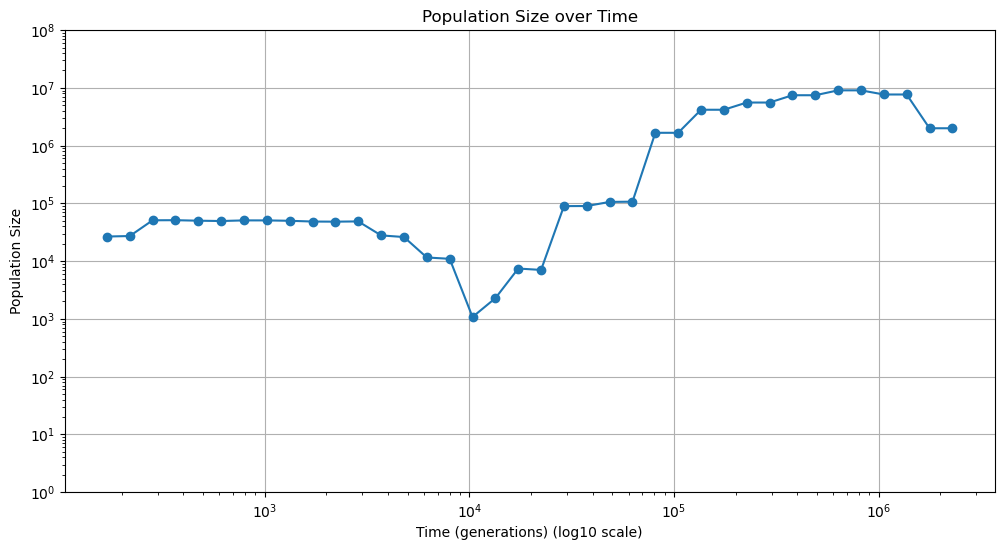

In [91]:

size_changes = [event for event in demography.events if isinstance(event, msprime.PopulationParametersChange)]
change_times = [event.time for event in size_changes]
change_sizes = [event.initial_size for event in size_changes]

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(change_times, change_sizes, marker='o')
plt.xlabel('Time (generations) (log10 scale)')
plt.ylabel('Population Size')
plt.title('Population Size over Time')
plt.grid(True)

# Use a logarithmic scale for population size
plt.yscale('log')
plt.ylim(1, 1e8)
plt.xscale('log')


plt.show()


In [132]:
sample_size= 10
L=1_000_000
# Simulate ancestry
ts= msprime.sim_ancestry(samples=sample_size, recombination_rate=1e-8,
                                 sequence_length=1e6, demography=demography, ploidy=1)

tsb= msprime.sim_ancestry(samples=sample_size, recombination_rate=1e-8,
                                 sequence_length=1e6, demography=demography,
                                 ploidy=1, model=msprime.BetaCoalescent(alpha=1.99))
# If you want to add mutations
mts = msprime.sim_mutations(ts, rate=1e-9)
mtsb = msprime.sim_mutations(tsb, rate=1e-9)
mts


In [133]:
mtsb

In [193]:
sample_size=10
demography_model = msprime.Demography()
demography_model.add_population(initial_size=smooth_pop_sizes[0])
# Add population size changes
for t, size in zip(population_times[1:], smooth_pop_sizes[1:]):
    demography_model.add_population_parameters_change(time=t, initial_size=size)

    
ts = msprime.sim_ancestry(samples=sample_size, recombination_rate=1e-8,
                                 sequence_length=1_000_000, demography=demography_model,
                                 ploidy=1, model=msprime.BetaCoalescent(alpha=1.4))
# If you want to add mutations
mts = msprime.sim_mutations(ts, rate=1e-8)

In [49]:
def simulate_beta_coalescent(alpha, population_time, demography, L, r, sample_size):
    """Simulate tree sequences using the Beta coalescent model with a given alpha."""
    demography_model = msprime.Demography()
    
    # Set the initial population size based on the most recent population size (at time = 0)
    demography_model.add_population(initial_size=demography[0])

    # Convert population_time to positive time values for sorting
    positive_times = [abs(t) for t in population_time[1:]]  # Negate to get positive time values
    sizes = demography[1:]

    # Create a list of tuples and sort by time
    events = sorted(zip(positive_times, sizes))

    # Add population parameter changes in order
    for time, size in events:
        demography_model.add_population_parameters_change(time=time, initial_size=size)
    
    return msprime.sim_ancestry(samples=sample_size, recombination_rate=r,
                                 sequence_length=L, demography=demography_model,
                                 ploidy=1, model=msprime.BetaCoalescent(alpha=alpha)
                                 )

    

In [251]:
# User-defined parameters
num_time_points = 39  # Number of time points for demographic changes


# Demographic data
demography_data = {
    'years_ago': [
        20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
        75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
        273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
        990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
        3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
        12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
        46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
        169890.48403, 219724.30843, 284175.84417, 367532.89150
    ],
    'Ne_log10': [
        3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
        4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
        4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
        4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
        3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
        6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
        6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
        6.885372, 6.885372, 6.300497, 6.300497
    ]
}

# Convert to DataFrame for easier manipulation
demography_df = pd.DataFrame(demography_data)

# Function to randomly sample parameters
def sample_random_params():
    beta_alpha = np.random.uniform(1, 1.9)  # Random alpha for Beta coalescent
    nearly_kingman_alpha = np.random.uniform(1.9, 1.991)  # Random alpha for nearly Kingman-like
    mutation_rate = np.exp(np.random.uniform(np.log(1e-10), np.log(1e-9)))
    recombination_rate = np.exp(np.random.uniform(np.log(1e-7), np.log(1e-6)))
    return beta_alpha, nearly_kingman_alpha, mutation_rate, recombination_rate

# Function to generate population times
def get_population_time(num_time_points):
    """Generate population times."""
    divided_years = demography_df['years_ago'] / 0.16  # Divide years_ago by generation time
    return np.linspace(min(divided_years), max(divided_years), num_time_points)  # Select evenly spaced time points

def sample_population_size(num_time_points, demography_fromdata):
    """Sample population sizes based on demographic data."""
    pop_sizes = np.zeros(num_time_points)
    
    # Ensure demography_df has enough rows
    total_rows = len(demography_fromdata)
    if total_rows == 0:
        raise ValueError("The demography DataFrame is empty.")
    
    # Adjust the loop to prevent out-of-bounds indexing
    for i in range(num_time_points):
        if i >= total_rows:
            raise IndexError(f"Index {i} is out of bounds for demography DataFrame with {total_rows} rows.")
        
        log10_Ne = demography_fromdata['Ne_log10'].iloc[i]
        Ne = 10 ** log10_Ne
        pop_sizes[i] = np.random.uniform(max(0, Ne - 1000), Ne + 1000)  # Sample within ±1000 around the population size
    
    return pop_sizes


# Function to simulate a Beta coalescent
def simulate_beta_coalescent(alpha, population_time, population_size, L, r, sample_size):
    """Simulate tree sequences using the Beta coalescent model with a given alpha."""
    demography_model = msprime.Demography()
    demography_model.add_population(initial_size=population_size[0])
    for time, size in zip(population_time[1:], population_size[1:]):
        demography_model.add_population_parameters_change(time=time, initial_size=size)
    
    return msprime.sim_ancestry(samples=sample_size, recombination_rate=r,
                                 sequence_length=L, demography=demography_model,
                                 ploidy=1, model=msprime.BetaCoalescent(alpha=alpha))


    
# Function to simulate Kingman coalescent
def simulate_kingman_coalescent(population_time, population_size, L, r, sample_size):
    """Simulate tree sequences using Kingman coalescent (default settings)."""
    demography_model = msprime.Demography()
    demography_model.add_population(initial_size=population_size[0])
    for time, size in zip(population_time[1:], population_size[1:]):
        demography_model.add_population_parameters_change(time=time, initial_size=size)
    
    return msprime.sim_ancestry(samples=sample_size, recombination_rate=r,
                                 sequence_length=L, demography=demography_model, ploidy=1)

# Function to apply mutations to a tree sequence
def mutate_tree_sequence(tree_sequence, mutation_rate):
    """Apply mutations to the given tree sequence based on the mutation rate."""
    return msprime.sim_mutations(tree_sequence, rate=mutation_rate)

# Function to save simulation parameters to a text file
def save_parameters(seed, sim_id, beta_alpha, nearly_kingman_alpha, mutation_rate, recombination_rate, output_dir, file_name):
    """Save simulation parameters to a text file."""
    parameters = (f"Seed: {seed}\n"
                  f"Simulation no.: {sim_id}\n"
                  f"Beta Alpha: {beta_alpha}\n"
                  f"Nearly Kingman Alpha: {nearly_kingman_alpha}\n"
                  f"Mutation Rate: {mutation_rate}\n"
                  f"Recombination Rate: {recombination_rate}\n")
    
    with open(os.path.join(output_dir, file_name), 'w') as f:
        f.write(parameters)


# Function to save tree sequences to Gzip format
def save_tree_sequences(tree, L, output_format, output_dir, file_prefix):
    """Save the tree sequences in the specified format."""
    if output_format == 'vcf':
        vcf_file_path = os.path.join(output_dir, f"{file_prefix}.vcf")
        with open(vcf_file_path, 'w') as output_file:
            tree.write_vcf(output_file)

        # Save as Gzip
        with open(vcf_file_path, 'rb') as f_in:
            with gzip.open(vcf_file_path + '.gz', 'wb') as f_out:
                f_out.writelines(f_in)
      #  os.remove(vcf_file_path)  # Remove the original file after compression

    else:  # For tree sequence format
        ts_file_path = os.path.join(output_dir, f"{file_prefix}.ts")
        tree.dump(ts_file_path)

        # Save as Gzip
        with open(ts_file_path, 'rb') as f_in:
            with gzip.open(ts_file_path + '.gz', 'wb') as f_out:
                f_out.writelines(f_in)
        os.remove(ts_file_path)  # Remove the original file after compression



In [253]:
# Function to run a single simulation
def run_single_simulation(seed, sim_id, output_format, output_dir, demography_fromdata, sample_size, L):
    """Run a single simulation and save the results."""
    # Set the seed for reproducibility
    np.random.seed(seed)
    
    population_times = get_population_time(num_time_points)
    smooth_pop_sizes = sample_population_size(num_time_points, demography_fromdata)

    beta_alpha, nearly_kingman_alpha, mutation_rate, recombination_rate = sample_random_params()
    
    # Run simulations
    kingman_tree = simulate_kingman_coalescent(population_times, smooth_pop_sizes, L, recombination_rate, sample_size)
    beta_tree = simulate_beta_coalescent(beta_alpha, population_times, smooth_pop_sizes, L, recombination_rate, sample_size)
    nearly_kingman_tree = simulate_beta_coalescent(nearly_kingman_alpha, population_times, smooth_pop_sizes, L, recombination_rate, sample_size)
    
    # Apply mutations to the tree sequences
    kingman_tree_with_mutations = mutate_tree_sequence(kingman_tree, mutation_rate)
    beta_tree_with_mutations = mutate_tree_sequence(beta_tree, mutation_rate)
    nearly_kingman_tree_with_mutations = mutate_tree_sequence(nearly_kingman_tree, mutation_rate)
    

    return kingman_tree_with_mutations, beta_tree_with_mutations, nearly_kingman_tree_with_mutations
    # Save the mutated tree sequences
    #save_tree_sequences(kingman_tree_with_mutations, L, output_format, output_dir, f"kingman_{sim_id}_seed_{seed}")
    #save_tree_sequences(beta_tree_with_mutations, L, output_format, output_dir, f"beta_{sim_id}_seed_{seed}")
    #save_tree_sequences(nearly_kingman_tree_with_mutations, L, output_format, output_dir, f"nearly_kingman_{sim_id}_seed_{seed}")


In [ ]:
beta_alpha, nearly_kingman_alpha, mutation_rate, recombination_rate = sample_random_params()
    
    # Run simulations
kingman_tree = simulate_kingman_coalescent(population_times, smooth_pop_sizes, L, recombination_rate, sample_size)
beta_tree = simulate_beta_coalescent(beta_alpha, population_times, smooth_pop_sizes, L, recombination_rate, sample_size)
nearly_kingman_tree = simulate_beta_coalescent(nearly_kingman_alpha, population_times, smooth_pop_sizes, L, recombination_rate, sample_size)
    
    # Apply mutations to the tree sequences
kingman_tree_with_mutations = mutate_tree_sequence(kingman_tree, mutation_rate)
beta_tree_with_mutations = mutate_tree_sequence(beta_tree, mutation_rate)
nearly_kingman_tree_with_mutations = mutate_tree_sequence(nearly_kingman_tree, mutation_rate)
    


In [247]:
out_dir='/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1'
seed=1002
sample_size=3
L=1_000_000
sim_id=2
output_format='vcf'

In [228]:
# Run a single simulation based on provided arguments
a, b, c =run_single_simulation(seed, sim_id, output_format, out_dir, demography_df, sample_size, L)


In [261]:
population_times = get_population_time(num_time_points)
smooth_pop_sizes = sample_population_size(num_time_points, demography_df)

beta_alpha, nearly_kingman_alpha, mutation_rate, recombination_rate = sample_random_params()
    
# Run simulations
kingman_tree = simulate_kingman_coalescent(population_times, smooth_pop_sizes, L, recombination_rate, sample_size)
beta_tree = simulate_beta_coalescent(beta_alpha, population_times, smooth_pop_sizes, L, recombination_rate, sample_size)
nearly_kingman_tree = simulate_beta_coalescent(nearly_kingman_alpha, population_times, smooth_pop_sizes, L, recombination_rate, sample_size)
    
# Apply mutations to the tree sequences
kingman_tree_with_mutations = mutate_tree_sequence(kingman_tree, mutation_rate)
beta_tree_with_mutations = mutate_tree_sequence(beta_tree, mutation_rate)
nearly_kingman_tree_with_mutations = mutate_tree_sequence(nearly_kingman_tree, mutation_rate)
    


In [260]:
kingman_tree_with_mutations

In [249]:
kingman_tree_with_mutations

In [217]:
import os
import msprime

# Simulate Kingman coalescent tree (assuming you already have a tree sequence `kingman_tree`)
mutation_rate = 1e-7

# Apply mutations to the tree sequence
mts = msprime.sim_mutations(kingman_tree, rate=mutation_rate)

# Print the mutated tree sequence
print(mts)

# Ensure the output directory exists
out_dir='/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1'
os.makedirs(out_dir, exist_ok=True)

# Specify the VCF file path
vcf_file_path = os.path.join(out_dir, "file_trial_kingman_prefix.vcf")

# Open the VCF file in write mode and write the mutated tree sequence as VCF
with open(vcf_file_path, 'w') as vcf_file:
    mts.write_vcf(vcf_file)

print(f"VCF file written to: {vcf_file_path}")




╔═══════════════════════════╗
║TreeSequence               ║
╠═══════════════╤═══════════╣
║Trees          │        628║
╟───────────────┼───────────╢
║Sequence Length│     100000║
╟───────────────┼───────────╢
║Time Units     │generations║
╟───────────────┼───────────╢
║Sample Nodes   │          3║
╟───────────────┼───────────╢
║Total Size     │   95.2 KiB║
╚═══════════════╧═══════════╝
╔═══════════╤════╤═════════╤════════════╗
║Table      │Rows│Size     │Has Metadata║
╠═══════════╪════╪═════════╪════════════╣
║Edges      │1548│ 48.4 KiB│          No║
╟───────────┼────┼─────────┼────────────╢
║Individuals│   3│108 Bytes│          No║
╟───────────┼────┼─────────┼────────────╢
║Migrations │   0│  8 Bytes│          No║
╟───────────┼────┼─────────┼────────────╢
║Mutations  │ 236│  8.5 KiB│          No║
╟───────────┼────┼─────────┼────────────╢
║Nodes      │ 489│ 13.4 KiB│          No║
╟───────────┼────┼─────────┼────────────╢
║Populations│   1│224 Bytes│         Yes║
╟───────────┼────┼────

In [27]:
kingman_tree_with_mutations = mutate_tree_sequence(kingman_tree, mutation_rate)
beta_tree_with_mutations = mutate_tree_sequence(beta_tree, mutation_rate)
nearly_kingman_tree_with_mutations = mutate_tree_sequence(nearly_kingman_tree, mutation_rate)


In [40]:
kingman_tree_with_mutations


In [28]:
kingman_tree_with_mutations

In [ ]:
# Save parameters and tree sequences
file_suffix_kingman = f"sim_{sim_id}_seed_{seed}"  # Use sim_id instead of seed for the filename
file_suffix_alpha = f"sim_{sim_id}_seed_{seed}_alpha_{round(beta_alpha, 2)}"  # Use sim_id instead of seed for the filename
file_suffix_nearlykingman = f"sim_{sim_id}_seed_{seed}_alpha_{round(nearly_kingman_alpha, 2)}"  # Use sim_id instead of seed for the filename
save_parameters(seed, sim_id, beta_alpha, nearly_kingman_alpha, mutation_rate, recombination_rate, output_dir, f"{file_suffix_kingman}_params.txt")
    

In [3]:

def get_population_time(time_rate:float=0.06, tmax:int = 130_000,
                        num_time_windows:int = 21
                       ) -> np.array :
    population_time = np.repeat([(np.exp(np.log(1 + time_rate * tmax) * i /
                              (num_time_windows - 1)) - 1) / time_rate for i in
                              range(num_time_windows)], 1, axis=0)
    population_time[0] = 1
    return population_time



def get_updated_population_timey(steps = 18):
    x = np.log(get_population_time(time_rate=0.1, num_time_windows=steps, tmax=10_000_000).tolist())
    xnew = np.linspace(x[0], x[-1], num=10000, endpoint=True)
    x_sample = xnew[np.linspace(10, 9999, 60).astype(int)]
    population_time = np.exp(x_sample)
    return population_time

population_time = get_updated_population_timey()

In [11]:
def beta_sawtooth(alpha, Ne=10**6, L=10_000_000, sample_size = 10, r = 1e-8, m=1e-7, ploidy = 1):   
    
    pref = "r" + str(r) + "m" + str(m) + "_"
    demography=msprime.Demography()
    demography.add_population(initial_size=(Ne))
    demography.add_population_parameters_change(time=20, population=None, growth_rate=6437.7516497364/(4*10**4))
    demography.add_population_parameters_change(time=30, growth_rate=-378.691273513906/(4*10**4))
    demography.add_population_parameters_change(time=200, growth_rate=-643.77516497364/(4*10**4))
    demography.add_population_parameters_change(time=300, growth_rate=37.8691273513906/(4*10**4))
    demography.add_population_parameters_change(time=2000, growth_rate=64.377516497364/(4*10**4))
    demography.add_population_parameters_change(time=3000, growth_rate=-3.78691273513906/(4*10**4))
    demography.add_population_parameters_change(time=20000, growth_rate=-6.4377516497364/(4*10**4))
    demography.add_population_parameters_change(time=30000, growth_rate=0.378691273513906/(4*10**4))
    demography.add_population_parameters_change(time=200000, growth_rate=0.64377516497364/(4*10**4))
    demography.add_population_parameters_change(time=300000, growth_rate=-0.0378691273513906/(4*10**4))
    demography.add_population_parameters_change(time=2000000, growth_rate=-0.064377516497364/(4*10**4))
    demography.add_population_parameters_change(time=3000000, growth_rate=0.00378691273513906/(4*10**4))
    demography.add_population_parameters_change(time=20000000, growth_rate=0, initial_size=Ne)
    db = msprime.DemographyDebugger(demography=demography)
    tree_sequences = []
    
    n = sample_size
    for i in range(10):
        
        tree_sequence = msprime.sim_ancestry(samples=sample_size, recombination_rate=r,sequence_length=L, demography=demography,ploidy=1,random_seed=((alpha*i+1)**2), model=msprime.BetaCoalescent(alpha=alpha))
        tree_sequence = msprime.mutate(tree_sequence, rate=m)
        vcfdir='/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1'
        vcffh = open(vcfdir+'beta_sim_' + str(alpha) + '_' + pref + str(i)+'.vcf', 'w')
        
        tree_sequence.write_vcf(vcffh, position_transform='legacy', individual_names=['spl'+str(s) for s in range(int(n))])
        vcffh.close()
        tsdir='/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1'
        tcdir='/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/trial1'
        tsfile = tsdir+'beta_sim_' + str(alpha) + "_" + pref + str(i)+'.trees'
        tree_sequence.dump(tsfile)
        for s1 in range(0, n-1):
            for s2 in range(s1+1, n):
                coaltimefh = open(tcdir+'/beta_' + str(alpha) + '_sim_'+ pref + str(i)+'_spls'+str(s1)+'-'+str(s2)+'.tc', 'w')
                for tree in tree_sequence.trees(): 
                    treeInterval = tree.get_interval() # length of sequence that this tree spans
                    coalescence_time = tree.tmrca(s1,s2)
                    print(treeInterval[0], treeInterval[1], coalescence_time, sep = "\t", file = coaltimefh)
                coaltimefh.close()
        
        tree_sequences.append(tree_sequence)
    demography = db.population_size_trajectory(population_time).flatten()
    return list(tree_sequences), demography 

In [12]:
tree_sequences,demography=beta_sawtooth(1.5)

In [ ]:
for tree_index, tree in enumerate(tree_sequence.trees()):
                for node in tree.nodes():
                    if tree.parent(node) != -1:  # Exclude root and samples
                        coalescent_time = tree.time(tree.parent(node)) - tree.time(node)